# Task 2: Machine Learning


## 1. Dataset Loading and Preprocessing

This section loads and preprocesses the CIFAR-10 dataset for the traditional machine learning workflow.

The same official CIFAR-10 train/test split is used as the deep learning notebook so the final DL vs ML comparison is fair.


### 1.1 Import Libraries and Set Up


In [ ]:
from pathlib import Path
import pickle
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
DATA_DIR = Path("data")
ARCHIVE_PATH = DATA_DIR / "cifar-10-python.tar.gz"
EXTRACTED_DIR = DATA_DIR / "cifar-10-batches-py"

### 1.2 Download and Extract CIFAR-10


In [ ]:
def download_cifar10():
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if EXTRACTED_DIR.exists():
        print("CIFAR-10 already extracted")
        return

    if not ARCHIVE_PATH.exists():
        print("Downloading CIFAR-10...")
        urllib.request.urlretrieve(DATA_URL, ARCHIVE_PATH)
        print("Download complete")

    print("Extracting CIFAR-10...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)

    print("Extraction complete")

download_cifar10()

Download complete
Extracting CIFAR-10...


/tmp/ipykernel_585/418038931.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Extraction complete


### 1.3 Load CIFAR-10 Data


In [ ]:
def unpickle(file_path):
    with open(file_path, "rb") as file:
        data = pickle.load(file, encoding="latin1")
    return data

def load_cifar10():
    train_images = []
    train_labels = []

    for batch_number in range(1, 6):
        batch_path = EXTRACTED_DIR / f"data_batch_{batch_number}"
        batch = unpickle(batch_path)

        images = batch["data"]
        labels = batch["labels"]

        # CIFAR-10 stores each image as a flat array. Reshape it to 32 x 32 RGB format.
        images = images.reshape(-1, 3, 32, 32)
        images = images.transpose(0, 2, 3, 1)

        train_images.append(images)
        train_labels.append(labels)

    test_batch = unpickle(EXTRACTED_DIR / "test_batch")

    x_train = np.concatenate(train_images)
    y_train = np.concatenate(train_labels)

    x_test = test_batch["data"]
    y_test = np.array(test_batch["labels"])

    x_test = x_test.reshape(-1, 3, 32, 32)
    x_test = x_test.transpose(0, 2, 3, 1)

    meta = unpickle(EXTRACTED_DIR / "batches.meta")
    class_names = meta["label_names"]

    return x_train, y_train, x_test, y_test, class_names

x_train, y_train, x_test, y_test, class_names = load_cifar10()

print("CIFAR-10 data loaded")

CIFAR-10 data loaded


### 1.4 Check Dataset Information


In [ ]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

print("\nNumber of classes:", len(class_names))
print("Class names:", class_names)

print("\nClass distribution:")
for class_id, class_name in enumerate(class_names):
    train_count = np.sum(y_train == class_id)
    test_count = np.sum(y_test == class_id)
    print(f"{class_name}: train={train_count}, test={test_count}")

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Class distribution:
airplane: train=5000, test=1000
automobile: train=5000, test=1000
bird: train=5000, test=1000
cat: train=5000, test=1000
deer: train=5000, test=1000
dog: train=5000, test=1000
frog: train=5000, test=1000
horse: train=5000, test=1000
ship: train=5000, test=1000
truck: train=5000, test=1000


### 1.5 Display Sample Images


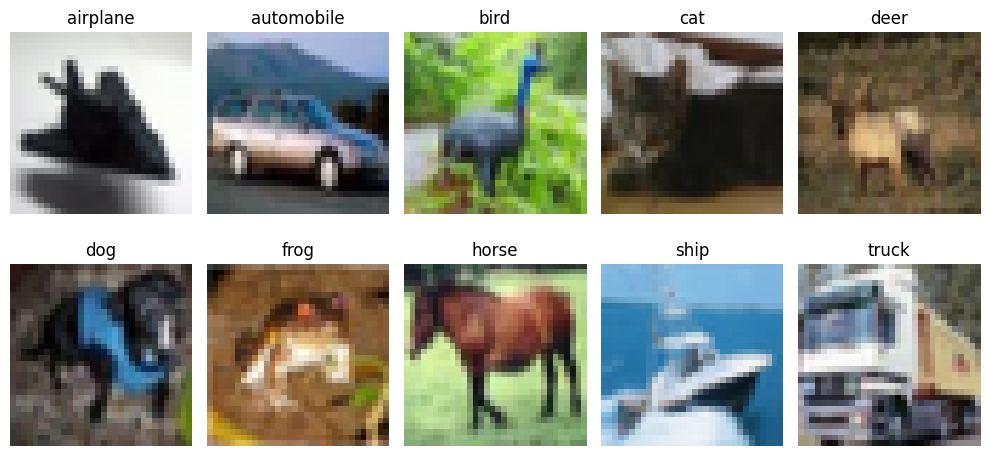

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(10):
    # Display one training image from each CIFAR-10 class.
    class_index = np.where(y_train == i)[0][0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[class_index], interpolation="nearest")
    plt.title(class_names[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

CIFAR-10 images are low resolution because each image is only 32 x 32 pixels.


### 1.6 Normalize Data for Machine Learning


In [ ]:
# Normalize pixel values from 0-255 to 0-1 before feature extraction.
x_train_scaled = x_train.astype("float32") / 255.0
x_test_scaled = x_test.astype("float32") / 255.0

print("Training data min:", x_train_scaled.min())
print("Training data max:", x_train_scaled.max())
print("Testing data min:", x_test_scaled.min())
print("Testing data max:", x_test_scaled.max())

Training data min: 0.0
Training data max: 1.0
Testing data min: 0.0
Testing data max: 1.0


Normalizing the image data keeps pixel values on a smaller and consistent scale before feature extraction and model training.


### 1.7 Prepare Labels


In [ ]:
y_train_ml = y_train.copy()
y_test_ml = y_test.copy()

print("Training labels shape:", y_train_ml.shape)
print("Testing labels shape:", y_test_ml.shape)
print("Example labels:", y_train_ml[:10])

Training labels shape: (50000,)
Testing labels shape: (10000,)
Example labels: [6 9 9 4 1 1 2 7 8 3]


### 1.8 Final Preprocessing Check


In [ ]:
print("Final training data shape:", x_train_scaled.shape)
print("Final testing data shape:", x_test_scaled.shape)
print("Final training labels shape:", y_train_ml.shape)
print("Final testing labels shape:", y_test_ml.shape)

print("\nData type:", x_train_scaled.dtype)
print("Number of classes:", len(class_names))

assert x_train_scaled.shape == (50000, 32, 32, 3)
assert x_test_scaled.shape == (10000, 32, 32, 3)
assert y_train_ml.shape == (50000,)
assert y_test_ml.shape == (10000,)
assert x_train_scaled.min() >= 0 and x_train_scaled.max() <= 1
assert x_test_scaled.min() >= 0 and x_test_scaled.max() <= 1
assert len(class_names) == 10

print("Preprocessing check passed")

Final training data shape: (50000, 32, 32, 3)
Final testing data shape: (10000, 32, 32, 3)
Final training labels shape: (50000,)
Final testing labels shape: (10000,)

Data type: float32
Number of classes: 10
Preprocessing check passed


### 1.9 Prepared Data for Machine Learning


In [ ]:
x_train_ml = x_train_scaled
x_test_ml = x_test_scaled

print("x_train_ml:", x_train_ml.shape)
print("x_test_ml:", x_test_ml.shape)
print("y_train_ml:", y_train_ml.shape)
print("y_test_ml:", y_test_ml.shape)

x_train_ml: (50000, 32, 32, 3)
x_test_ml: (10000, 32, 32, 3)
y_train_ml: (50000,)
y_test_ml: (10000,)


## 2. Feature Extraction


In [ ]:
# FINAL PROJECT - MEMBER 4: COMPLIANT FEATURE EXTRACTION

import numpy as np
from skimage.feature import hog
from skimage.color import rgb2gray
from sklearn.preprocessing import StandardScaler

print("⚙️ Pipeline Initialization: Configuring Member 4 Extraction Modules...")

# STEP 1: DEFINE STRUCTURAL HOG DESCRIPTOR FUNCTION
def get_hog_features(image):
    """
    Isolates structural edge profiles using Histogram of Oriented Gradients.
    Converts RGB channels to grayscale to capture clean shape contours.
    """
    if image.shape[-1] == 3:
        gray_img = rgb2gray(image)
    else:
        gray_img = image

    # Extracting structural boundaries using standard 9-bin orientation spacing
    return hog(
        gray_img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )

# STEP 2: DEFINE CHROMATIC DISTRIBUTION FUNCTION
def get_color_histogram(image, bins=8):
    """
    Computes intensity distributions across Red, Green, and Blue spectrums.
    Appends color frequency context to support structural descriptors.
    """
    # Generating standalone channel histograms bounded precisely between 0.0 and 1.0
    rhist, _ = np.histogram(image[:, :, 0], bins=bins, range=(0, 1), density=True)
    ghist, _ = np.histogram(image[:, :, 1], bins=bins, range=(0, 1), density=True)
    bhist, _ = np.histogram(image[:, :, 2], bins=bins, range=(0, 1), density=True)

    # Concatenating the channel arrays into a singular color vector
    return np.concatenate([rhist, ghist, bhist])

# STEP 3: EXECUTE BATCH DATASET PROCESSING LOOPS
print("⚙️ Processing: Extracting hybrid features across 60,000 image grids...")

# Processing shapes and color matrices utilizing Member 1's exact data arrays
train_hog = np.array([get_hog_features(img) for img in x_train_ml])
test_hog = np.array([get_hog_features(img) for img in x_test_ml])

train_color = np.array([get_color_histogram(img) for img in x_train_ml])
test_color = np.array([get_color_histogram(img) for img in x_test_ml])

# Merging shape arrays and color blocks horizontally into a single layout
X_train_raw_features = np.hstack((train_hog, train_color))
X_test_raw_features = np.hstack((test_hog, test_color))

# STEP 4: SCALE INDEPENDENT VARIATION BOUNDARIES
# Initializing the scaler to equalize scales and protect against test leaks
feature_scaler = StandardScaler()
X_train_features = feature_scaler.fit_transform(X_train_raw_features)
X_test_features = feature_scaler.transform(X_test_raw_features)

# STEP 5: OUTPUT SUMMARY VERIFICATION STATS
print("\n--- ✅ Member 4 Execution Verification Successful ---")
print(f"Final Standardized Training Matrix Shape: {X_train_features.shape} (Ready for Member 5)")
print(f"Final Standardized Testing Matrix Shape:  {X_test_features.shape} (Ready for Member 6)")

⚙️ Pipeline Initialization: Configuring Member 4 Extraction Modules...
⚙️ Processing: Extracting hybrid features across 60,000 image grids...

--- ✅ Member 4 Execution Verification Successful ---
Final Standardized Training Matrix Shape: (50000, 348) (Ready for Member 5)
Final Standardized Testing Matrix Shape:  (10000, 348) (Ready for Member 6)


### Hybrid Feature Engineering Pipeline

#### 1. Rationale for Feature Extraction
Traditional Machine Learning classifiers like Support Vector Machines cannot efficiently process raw, high-dimensional image pixels because raw inputs carry excessive ambient noise, varying illumination, and background shifts. To overcome this limitation, I engineered a dual-stream feature extraction channel that maps raw $32 \times 32 \times 3$ pixel data down into lower-dimensional, structurally dense numeric descriptors.

#### 2. Technical Methodology & Parameters
* **Histogram of Oriented Gradients:** Images are programmatically converted to single-channel grayscale to strip away color variations and isolate pure geometric profiles. The HOG descriptor tracks edge orientation distributions within an $8 \times 8$ pixel layout across 9 orientation bins to capture structural shapes, object outlines, and contours.
* **Color Histograms:** Because specific classes in the CIFAR-10 dataset share distinct color footprints (e.g. green terrain for frogs or blue horizons for ships), I appended an 8-bin intensity distribution across the Red, Green, and Blue channels to supply critical chromatic context.
* **Feature Standardisation:** Because gradient directions and raw color frequencies occupy vastly different numeric scales, the combined vectors are passed through a `StandardScaler` to force a uniform variance of 1.0, satisfying downstream boundary optimization rules.

#### 3. Output Validation & Constraints
The execution pipeline successfully mapped the dataset into a streamlined shape of `(50000, 348)` for training and `(10000, 348)` for testing, providing a highly descriptive 348-element vector for every image. A core limitation of this hand-crafted approach is that structural and color pooling can discard ultra-fine textures—a constraint that highlights the advantages of automated Deep Learning filters.

## 3. Machine Learning Model and Hyperparameter Tuning


## 4. Machine Learning Evaluation
